### Caroline Capuano
### Final Project
# <span style="color:purple"> **Parametric Instabilities in High Power Fabry-Perot Cavities**


## <span style="color:darklavender"> What are parametric instabilities?

Parametric instabilities, or PIs, are a three-mode optomechanical feedback loop that can lead to instability in high power Fabry-Perot cavities. The three-modes involved are: the fundamental mode from the main laser $\omega_0$, acoustic mode of mirror $\omega_m$, and the higher order scattered sidebands $\omega_0 \pm \omega_w$. The higher order scattered sidebands are created by the scattering of the main laser off of the vibrating mirror. The high-order mode will return back to the mirror after cycling through the cavity, then couple with fundamental mode of the main laser. This radiation pressure can then feed into the acoustic mode of the mirror, causing exponential growth of that mode that can eventually lead to lock loss $^{[2]}$.

$$F_{\text{rad}} = \dfrac{2}{c} E_{\text{pump}}^* \sum_{n=0}^\infty B_{m,n} E_{\text{return, n}}$$

Instability occurs when the energy from this radiation pressure force "exceeds the mechanical dissipation of the mirror" $^{[5]}$. This will cause an exponential growth of the acoustic modes, which can eventually lead to a lock loss of the cavity. Specifically, the instability occurs when the **parametric gain** exceeds 1 (see parametric gain section). Blair describes this phenomenon as an "uncontrolled laser powered amplification of acoustic vibrations of the mirrors"$.^{[1]}$

To help understand this phenomenon, you can think of parametric instabilities as a 4 step feedback process once the acoustic modes are excited:
<div style="text-align: center;">

<img src="3_mode_pi_loop.png" alt="Arm Cavity" width="300">

<p style="font-size: 12px;"> Feedback loop from Mitchell Schiworski's Thesis <sup>[8]</sup></p>

</div>

For the radiation pressure force to be great enough to cause instability, certain conditions must be met. This notebook will look into each step of this feedback loop and consider how the geometric conditions of the modes, the power of the cavity, and the quality factor of the optic will impact the instability. 

1. When the pump field is reflected off of the mirror, the mirror's acoustic mode scatters the carrier light into a transverse higher order optical mode.
2. The higher order mode (HOM) gets amplified by the arm cavity
3. The beating between the carrier mode and the higher-order mode produces a radiation-pressure force back on the mirror.
4. If the feedback is strong enough into the acoustic mode $\omega_m$, the acoustic mode amplitude will grow exponentially


#### Why is this something high power Fabry-Perot cavities need to be concerned about? 

This was theorized to be a potential issue for high power Fabry-Perot cavities in 2001. 

> "The basis for this effect is the excitation of the additional (Stokes) optical mode with frequency $\omega_1$ and of the mirror’s elastic mode with frequency $\omega_m$ when the optical energy stored in the main FP resonator mode with frequency $\omega_0$ exceeds the certain threshold and the frequencies are related as $\omega_0 \simeq \omega_1 +\omega_m$. This effect is undesirable in laser gravitational wave antennae because it may create a specific upper limit for the value of energy stored in FP resonator. In order to avoid it the detailed analysis of the mirror’s elastic modes and FP resonator optical modes structure is necessary." $^{[6]}$.


In order to achieve a low enough sensitivity to detect gravitational waves, the optical power in the arm cavities must be very high. (For reference, LIGO's arm cavity reaches 1 MW.) This was later proven to be an issue that needed to be mitigated - the first demonstration of dampening this instability for a LIGO test mass was published in 2017 $^{[3]}$

With an arm cavity with that high of power, the produced radiation pressure force significantly alters the behavior of these optical cavities by producing this unstable feedback loop. Therefore, parametric instabilities can be seen as a **power-limiting** instability; At high enough power, acoustic modes of the mirror can ring up uncontrollably and can cause the interferometer to lose lock. So, PIs are a barrier to our sensitivity level if left undamped $^{[1]}$. Since we need a high power cavity to detect gravitational waves, then these amplified modes must be damped. 

I'll talk about how these modes are mitigated in LIGO later. We must first understand each part of this feedback loop that produces this instability and what conditions are needed to cause this unstable gain.


### <span style="color:lightblue">Mechanical and Acoustic Modes
Mechanical modes are the natural patterns of vibration that a solid object, like a mirror, can sustain. Every object has a discrete set of these patterns, each with its own characteristic frequency and shape. For example, when you strike a wine glass it rings at a specific pitch — that's its fundamental mechanical mode. 

In the context of parametric instabilities, like for a LIGO test mass, the relevant mechanical modes are the **internal acoustic modes** of the test mass. These are the natural elastic vibration patterns of the mirror, each with a discrete resonant frequency and a characteristic spatial deformation patterns. Each mode is characterized by three things: the eigenfrequency $\omega_m$ of the mode, the mode shape $\vec{u}_m(\vec{r})$, and the mechanical quality factor $Q_m$. The eigenfrequencies are the resonant frequencies of the given mode,  the mode shape describes which parts of the mirror surface move outward, which move inward, and which remain stationary at the nodes, and the quality factor determines how energy is dissipated in the optic. 

This can be estimated by the sum of the loss for each part of the mirror. Below is an example for a LIGO test mass $^{[1]}$

$$Q_m = \dfrac{1}{\phi_{\text{total}}}; \quad \text{where} \space \space\phi_{\text{total}} = \phi_{\text{substrate}} + \phi_{\text{coating}} + \phi_{\text{geometry}}+\phi_{\text{suspension}}$$


Examples of test-mass acoustic mode shapes include the **butterfly** and **drumhead** modes shown below. These are useful for visualizing how different parts of the mirror surface move with opposite phase, which is what enables the mechanical motion to scatter light into other optical modes. Regions of large motion are called antinodes, while nodes remain nearly stationary.


<div style="display: flex; justify-content: center; gap: 40px; align-items: flex-start;">

  <div style="text-align: center;">
    <img src="butterfly_mode.png" width="400">
    <p><b>Butterfly Mode</b><sup>[10]</sup></p>
  </div>

  <div style="text-align: center;">
    <img src="drum_mode.png" width="400">
    <p><b>Drumhead Mode</b><sup>[10]</sup></p>
  </div>

</div>

These properties are important for parametric instabilities because a vibrating test mass can phase-modulate the reflected carrier field and scatter light from the fundamental optical mode into higher-order optical modes. A mechanical mode couples most strongly when its surface deformation overlaps the laser beam's spatial structure. In this way, the mode shape directly affects the strength of the optomechanical coupling.

### <span style="color:orange">Step 1: Scattering Carrier Light

The arm cavity contains a strong circulating carrier field, I'll be calling it the **pump field**, which is ideally in the fundamental Gaussian cavity mode $(\mathrm{TEM}_{00})$. The acoustic modes of the mirror add a small phase modulation to the reflected carrier field.

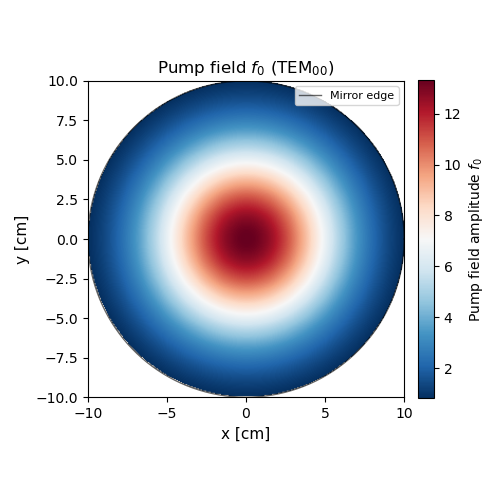

In [42]:

import numpy as np
import matplotlib.pyplot as plt

N = 300   # resolution
mirror_r = 0.1  # mirror radius [m]
beam_waist = 0.06  # beam waist [m]

x = np.linspace(-mirror_r, mirror_r, N)
dx = x[1] - x[0]
dA = dx**2

xx, yy = np.meshgrid(x, x)  
r = np.sqrt(xx**2 + yy**2)
mask = r <= mirror_r  # only keep points on the mirror

def gaussian_beam(xx, yy, beam_waist, mask=None):
    """
    Amplitude of the pump field (TEM00 Gaussian beam).
    """
    f = np.exp(-(xx**2 + yy**2) / beam_waist**2)

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA) # normalize
    f /= norm
    return f

f0 = gaussian_beam(xx, yy, beam_waist, mask=mask)
f0_display = f0.copy()
f0_display[~mask] = np.nan

axis_lim = [
    -mirror_r * 100, mirror_r * 100, # x limits in cm
    -mirror_r * 100, mirror_r * 100  # y limits in cm
]

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('none')

im = ax.imshow(f0_display, extent=axis_lim, origin='lower', cmap='RdBu_r')

theta = np.linspace(0, 2 * np.pi, 300)

ax.plot(mirror_r * 100 * np.cos(theta), mirror_r * 100 * np.sin(theta), 'k-', lw=1.0, alpha=0.6, label='Mirror edge')

plt.colorbar(im, ax=ax, label=r'Pump field amplitude $f_0$', fraction=0.046, pad=0.04)

ax.set_xlabel('x [cm]', fontsize=11)
ax.set_ylabel('y [cm]', fontsize=11)
ax.set_title(r'Pump field $f_0$ (TEM$_{00}$)', fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('pump_field.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

"Small mechanical oscillations with the resonance frequency $\omega_m$ modulate the distance L that causes the excitation optical fields with frequencies $\omega_0 \pm \omega_m$", *Parametric Oscillatory Instability in Fabry-Perot (FP) Interferometer* $^{[6]}$.

<details>
<summary><b>Click to expand derivation of the sidebands from a vibrating mirror</b></summary>

We take the incident field to be

$$
E_{\rm in}(t)=E_0 e^{i\omega_0 t},
$$

and let the mirror surface vibrate as

$$
x(t)=x_m \cos(\omega_m t).
$$

Reflection from a moving mirror adds a phase shift proportional to the changing optical path length, so the reflected field is

$$
E_{\rm r}(t)\propto E_0 e^{i\omega_0 t} e^{\,i\,2k x(t)},
\qquad
k=\frac{2\pi}{\lambda_0}.
$$

Substituting \(x(t)\) gives

$$
E_{\rm r}(t)\propto E_0 e^{i\omega_0 t} e^{\,i\,2k x_m \cos(\omega_m t)}.
$$

For small motion, $2k x_m \ll 1$, expand the exponential to first order:

$$
e^{i\,2k x_m \cos(\omega_m t)}
\approx
1+i\,2k x_m \cos(\omega_m t).
$$

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
\left[
1+i\,2k x_m \cos(\omega_m t)
\right].
$$

Using this relation,

$$
\cos(\omega_m t)=\frac{1}{2}\left(e^{i\omega_m t}+e^{-i\omega_m t}\right),
$$

we can simplify

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
\left[
1+i\,2k x_m \cdot \frac{1}{2}\left(e^{i\omega_m t}+e^{-i\omega_m t}\right)
\right] \approx
E_0 e^{i\omega_0 t}
\left[
1+i k x_m e^{i\omega_m t}+i k x_m e^{-i\omega_m t}
\right].
$$

Distributing the carrier factor $e^{i\omega_0 t}$,

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
+
i k x_m E_0 e^{i(\omega_0+\omega_m)t}
+
i k x_m E_0 e^{i(\omega_0-\omega_m)t}.
$$

So the reflected field contains three frequency components:

$$
\omega_0,
\qquad
\omega_0+\omega_m,
\qquad
\omega_0-\omega_m.
$$

Therefore the vibration of the mirror phase-modulates the carrier and produces upper and lower sidebands!

</details>


If the surface displacement oscillates at the mechanical frequency $(\omega_m)$, then the reflected field acquires sidebands at frequencies $(\omega_0 \pm \omega_m)$, where $(\omega_0)$ is the carrier frequency. In the language of parametric instabilities, these are the **anti-Stokes** and **Stokes** sidebands $^{[6]}$.

For parametric instability, however, the effect is not only a frequency modulation. The reason I wanted to show what the surface distribution should look like is because a key aspect of the scattering is the overlap of the fundamental mode of the laser and the vibrating mechanical mode of the mirror. The overlap between these two modes is what causes the scattered light $B_{m,n}$. Because the mechanical displacement has a spatial pattern $u_m(\vec r)$, the phase shift varies across the mirror surface. This means the vibrating mirror does not simply modulate the carrier in time; it also **scatters light out of the fundamental mode and into higher-order transverse optical modes**. Which optical modes are excited depends on the spatial overlap between the acoustic mode shape and the cavity optical modes.


$$B_{m,n} = \iint_{\text{surface}} f_0 \, f_n (\vec{u}_m \cdot \hat{z}) \, d\vec{r}_\perp$$

$$ E_{\text{scatt,n}}=\dfrac{2 \pi i}{\lambda_0} A_m E_{\text{pump}} B_{m,n} $$


$A_m$ is the amplitude of the mechanical mode, $E_{\text{pump}}$ is the electric field of the pump field, and $B_{m,n}$ is the modal overlap. This is the first step in the parametric instability loop. 

If the mechanical mode has a spatial pattern that overlaps with a particular higher order optical mode, energy transfers efficiently into that mode. If the shapes are orthogonal, no scattering will occur into that mode regardless of how strongly the mirror vibrates, i.e. *if the mechanical mode has a node where the optical mode has an antinode, they cancel out and very little scattering occurs.*



#### Scattered light, so what?
Once scattered into a HOM, the light doesn't just escape — it keeps circulating in the cavity.

Using the overlap equation above, Hermite-Gaussian HG(p,q) mode, and a gaussian fundamental mode, I was able to reproduce the resulting scattered HOM.

Output()

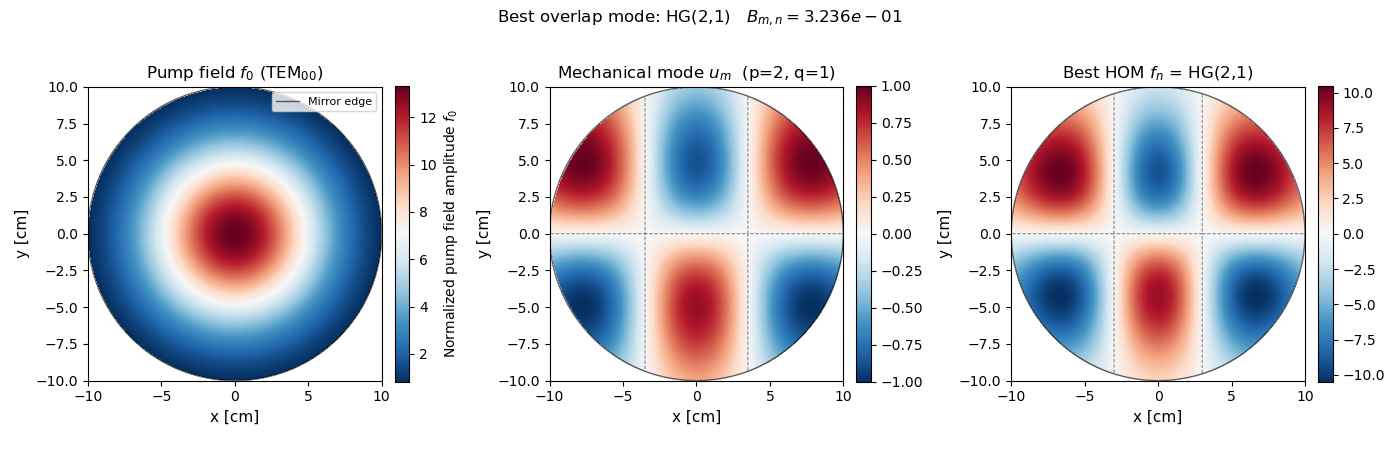

In [43]:
%matplotlib widget

from matplotlib.colors import TwoSlopeNorm
from scipy.special import hermite
import ipywidgets as widgets
from IPython.display import display


N = 300
mirror_r = 0.10
beam_waist = 0.06

x = np.linspace(-mirror_r, mirror_r, N)
dx = x[1] - x[0] # slope
dA = dx**2 # area

xx, yy = np.meshgrid(x, x)
r = np.sqrt(xx**2 + yy**2)
mask = r <= mirror_r

axis_lim = [
    -mirror_r * 100, mirror_r * 100, # cm
    -mirror_r * 100, mirror_r * 100  # cm
]

theta = np.linspace(0, 2 * np.pi, 300)

def signed_norm(arr):
    """
    center colormap at zero for fields
    """
    arr_valid = arr[np.isfinite(arr)]
    vmax = np.max(np.abs(arr_valid)) if arr_valid.size > 0 else 1.0
    if vmax == 0:
        vmax = 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


def gaussian_beam(xx, yy, beam_waist, mask=None):
    """
    amplitude of the pump field (TEM00 Gaussian beam).
    """
    f = np.exp(-(xx**2 + yy**2) / beam_waist**2)

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA)
    f /= norm
    return f


def hermite_gauss(p, q, xx, yy, beam_waist, mask=None):
    """
    normalized Hermite-Gaussian HG(p,q) mode.
    """

    Hp = hermite(p)(np.sqrt(2) * xx / beam_waist)
    Hq = hermite(q)(np.sqrt(2) * yy / beam_waist)
    env = np.exp(-(xx**2 + yy**2) / beam_waist**2)

    f = Hp * Hq * env

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA)
    if norm > 0:
        f /= norm

    return f


def mechanical_mode(xx, yy, p_mech, q_mech, mirror_r, mask=None):
    """
    mechanical mode shape
    """
    scale = 0.7 * mirror_r
    Hp = hermite(p_mech)(np.sqrt(2) * xx / scale)
    Hq = hermite(q_mech)(np.sqrt(2) * yy / scale)
    env = np.exp(-(xx**2 + yy**2) / scale**2)

    u = Hp * Hq * env

    if mask is not None:
        u = np.where(mask, u, 0.0)

    maxabs = np.max(np.abs(u))
    if maxabs > 0:
        u /= maxabs

    return u


def compute_best_hom(u_m, f0, max_order=6):
    """
    search HG modes up to total order = max_order and return the one with the largest |B_mn|.
    """
    best_pair = None
    best_B = None
    best_fn = None

    for total_order in range(max_order + 1):
        for p in range(total_order + 1):
            q = total_order - p

            fn = hermite_gauss(p, q, xx, yy, beam_waist, mask=mask)
            integrand = f0 * fn * u_m
            B_mn = np.sum(integrand) * dA

            if (best_B is None) or (abs(B_mn) > abs(best_B)):
                best_B = B_mn
                best_pair = (p, q)
                best_fn = fn

    return best_pair, best_B, best_fn


f0 = gaussian_beam(xx, yy, beam_waist, mask=mask)
f0_display = f0.copy()
f0_display[~mask] = np.nan

# initial settings
p0, q0 = 2, 1
u0 = mechanical_mode(xx, yy, p0, q0, mirror_r, mask=mask)
(best_pq, best_B, best_fn) = compute_best_hom(u0, f0, max_order=6)
pb, qb = best_pq


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

def draw_fundamental(ax):
    ax.clear()
    ax.set_facecolor('none')

    im = ax.imshow(f0_display, extent=axis_lim, origin='lower', cmap='RdBu_r')

    ax.plot(mirror_r * 100 * np.cos(theta), mirror_r * 100 * np.sin(theta), 'k-', lw=1.0, alpha=0.6, label='Mirror edge')

    ax.set_xlabel('x [cm]', fontsize=11)
    ax.set_ylabel('y [cm]', fontsize=11)
    ax.set_title(r'Pump field $f_0$ (TEM$_{00}$)', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
    return im


def draw_mechanical(ax, u_m, p_mech, q_mech):
    ax.clear()
    ax.set_facecolor('none')

    u_display = u_m.copy()
    u_display[~mask] = np.nan

    im = ax.imshow(u_display, extent=axis_lim, origin='lower', cmap='RdBu_r', norm=signed_norm(u_display))

    ax.plot( mirror_r * 100 * np.cos(theta), mirror_r * 100 * np.sin(theta), 'k-', lw=1.0, alpha=0.6)

    ax.contour( x * 100, x * 100, u_display,levels=[0], colors='k', linewidths=0.7, linestyles='--', alpha=0.5)

    ax.set_xlabel('x [cm]', fontsize=11)
    ax.set_ylabel('y [cm]', fontsize=11)
    ax.set_title(rf'Mechanical mode $u_m$  (p={p_mech}, q={q_mech})', fontsize=12)
    ax.set_aspect('equal')
    return im


def draw_best_hom(ax, fn_best, pb, qb):
    ax.clear()
    ax.set_facecolor('none')

    fn_display = fn_best.copy()
    fn_display[~mask] = np.nan

    im = ax.imshow( fn_display, extent=axis_lim, origin='lower', cmap='RdBu_r', norm=signed_norm(fn_display))

    ax.plot( mirror_r * 100 * np.cos(theta), mirror_r * 100 * np.sin(theta), 'k-', lw=1.0, alpha=0.6)

    ax.contour( x * 100, x * 100, fn_display, levels=[0], colors='k', linewidths=0.7, linestyles='--', alpha=0.5)

    ax.set_xlabel('x [cm]', fontsize=11)
    ax.set_ylabel('y [cm]', fontsize=11)
    ax.set_title(rf'Best HOM $f_n$ = HG({pb},{qb})', fontsize=12)
    ax.set_aspect('equal')
    return im


# initial draw
im0 = draw_fundamental(axes[0])
im1 = draw_mechanical(axes[1], u0, p0, q0)
im2 = draw_best_hom(axes[2], best_fn, pb, qb)

# colorbars
cbar0 = fig.colorbar(
    im0, ax=axes[0],
    label=r'Normalized pump field amplitude $f_0$',
    fraction=0.046, pad=0.04
)
cbar1 = fig.colorbar(
    im1, ax=axes[1],
    fraction=0.046, pad=0.04
)
cbar2 = fig.colorbar(
    im2, ax=axes[2],
    fraction=0.046, pad=0.04
)

fig.suptitle(
    rf'Best overlap mode: HG({pb},{qb})   $B_{{m,n}} = {best_B:.3e}$',
    fontsize=12
)

plt.tight_layout()

def update(p_mech, q_mech):
    global cbar1, cbar2

    u_m = mechanical_mode(xx, yy, p_mech, q_mech, mirror_r, mask=mask)
    (pb, qb), B_val, fn_best = compute_best_hom(u_m, f0, max_order=6)

    # remove old colorbars for panels 2 and 3
    cbar1.remove()
    cbar2.remove()

    # redraw panels 2 and 3 completely
    im1_new = draw_mechanical(axes[1], u_m, p_mech, q_mech)
    im2_new = draw_best_hom(axes[2], fn_best, pb, qb)

    # add updated colorbars back
    cbar1 = fig.colorbar(
        im1_new, ax=axes[1],
        fraction=0.046, pad=0.04
    )
    cbar2 = fig.colorbar(
        im2_new, ax=axes[2],
        fraction=0.046, pad=0.04
    )

    fig.suptitle(
        rf'Best overlap mode: HG({pb},{qb})   $B_{{m,n}} = {B_val:.3e}$',
        fontsize=12
    )
    fig.canvas.draw_idle()


slider_p = widgets.IntSlider( value=p0, min=0, max=5, step=1, description='p (mech)', style={'description_width': '80px'}, layout=widgets.Layout(width='350px'))

slider_q = widgets.IntSlider( value=q0, min=0, max=5, step=1, description='q (mech)', style={'description_width': '80px'}, layout=widgets.Layout(width='350px'))

label = widgets.HTML( value='<b>Mechanical mode indices:')

ui = widgets.VBox([label, widgets.HBox([slider_p, slider_q])])

out = widgets.interactive_output(update, {'p_mech': slider_p, 'q_mech': slider_q})

display(ui, out)

### <span style="color:lightcoral">Step 2: HOM in Cavity

Once the mechanical motion scatters carrier light into a higher-order optical mode, that scattered field propagates through the interferometer and returns to the same optic. According to Evans the optical system acts on each scattered mode through a complex transfer coefficient $(G_n)$, so that the returned field is $E_{\mathrm{rtrn},n} = G_n E_{\mathrm{scat},n}.$

The sidebands in the cavity will pick up a propagation phase  $p_L^\pm = e^{i(\phi_n \pm \omega_m L/c)},$ so the cavity response depends on both the HOM phase $(\phi_n)$ and the mechanical frequency $(\omega_m)$. The total optical feedback that contributes to radiation pressure is determined by the combination

$$
G_n = G_n^- - G_n^{+*}
$$

The difference between the lower- and upper-sideband responses is what matters for parametric instability $^{[2]}$.

Now that we know the basis, let's try and calculate $G_n$ by figuring out the scattering matrix (like we've done many times in class before). 

<div style="display: flex; justify-content: center; gap: 40px; align-items: flex-start;">

  <div style="text-align: center;">
    <img src="pi_cavity_w_drumhead.png" width="400">
    <p><b>Cavity with Drumhead Mode</b><sup>[10]</sup></p>
  </div>

  <div style="text-align: center;">
    <img src="cavity_equation.png" width="600">
    <p><b>Path in Cavity From "A General Approach to Optomechanical Parametric Instabilities"</b><sup>[2]</sup></p>
  </div>

</div>

Like we've done countless times in this class, let's now put together the scattering matrix so that we can calculate the gain from this cavity amplification: $G_n^{\pm} = \vec{e}_x^T(\mathbb{I}-S_n^{\pm})^{-1}\vec{e}_x$ where $\vec{e}_x$ is the basis vector, $S_n^{\pm}$ is the scattering matrix, and where $p^\pm_L = e^{i(\phi_n \pm \omega_m L/c)}$ is your propagation.

$\quad E_{\text{cav, 1}} = t_A E_{\text{in}} - r_A E_{\text{returned}}$

$\quad E_{\text{cav, 2}} = p^\pm_L E_{\text{cav, 1}}$

$\quad E_{\text{cav, 3}} = -r_B E_{\text{cav, 2}}$

$\quad E_{\text{returned}} = p^\pm_L E_{\text{cav, 3}}$


The scattering matrix is then:

$$
S^{\pm}_n=
\begin{pmatrix}
0 & 0 & 0 & 0 & 0 \\\\
t_A & 0 & 0 & 0 & -r_A \\\\
0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 0 & 0 & 0 \\\\
0 & 0 & -r_B & 0 & 0 \\\\
0 & 0 & 0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 0 \\\\
\end{pmatrix}
$$

Now lets subtract the scattering matrix by the identity matrix $\mathbb{I}$:

$$
\mathbb{I} - S^{\pm}_n=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\\\
-t_A & 1 & 0 & 0 & r_A \\\\
0 & -e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 1 & 0 & 0 \\\\
0 & 0 & r_B & 1 & 0 \\\\
0 & 0 & 0 & -e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 1 \\\\
\end{pmatrix}
$$

Now let's invert the matrix to get our transfer functions:

$$
(\mathbb{I} - S^{\pm}_n)^{-1}=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\\\

\dfrac{t_A}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{r_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_A e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_A}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\

\dfrac{t_Ae^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_A e^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_A e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\

-\dfrac{t_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_B}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{r_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\

-\dfrac{t_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
-\dfrac{r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} &
\dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}
\end{pmatrix}
$$

The basis vector $\vec{e}_x$ is $\vec{e}_x = $

$$
\vec{e}_x=
\begin{pmatrix}
0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Using this equation $G_n^{\pm} = \vec{e}_x^T(\mathbb{I}-S_n^{\pm})^{-1}\vec{e}_x$ with our basis vectors and scattering matrix, we can calculate that $G_n^{\pm}$ is:


$$\boxed{G_n^{\pm} = \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}}$$


Finally, using this equation, $G_n = G^-_n-G^{+*}_n$, we can calculate the gain coefficient of the cavity.

$$
\boxed{G_n = G^-_n-G^{+*}_n = \dfrac{1}{1-r_A r_Be^{2i(\phi_n - \dfrac{\omega_m L}{c})}} - \dfrac{1}{1-r_A r_Be^{-2i(\phi_n + \dfrac{\omega_m L}{c})}}} 
$$


Let's try adding some parameters so that we can solve the real part of this transfer function (this is what is needed to calculate the parametric gain). Parameters were taken from $\text{Miller, John, et al}^{[4]}$.


| Parameter (LIGO) |  Value |
|---------------|-----------------|
| Cavity Length [m] | 3994.5 |
| Input Mirror transmittance | 0.014 |
| End Mirror transmittance | $10^{-5}$ |
| Frequency of mode $\omega_m$ [Hz] | 29950 |
| Phase $\phi_n$ [rad] | n $\phi_{Gouy}$  |
| Phase $\phi_{Gouy}$ [deg] |  $156^\degree$  |


2.722713633111154
G_minus = 0.5018+0.0487j
G_plus = 0.5439+2.4432j
Gn = -0.0421+2.4919j
Re[Gn] = -0.0421


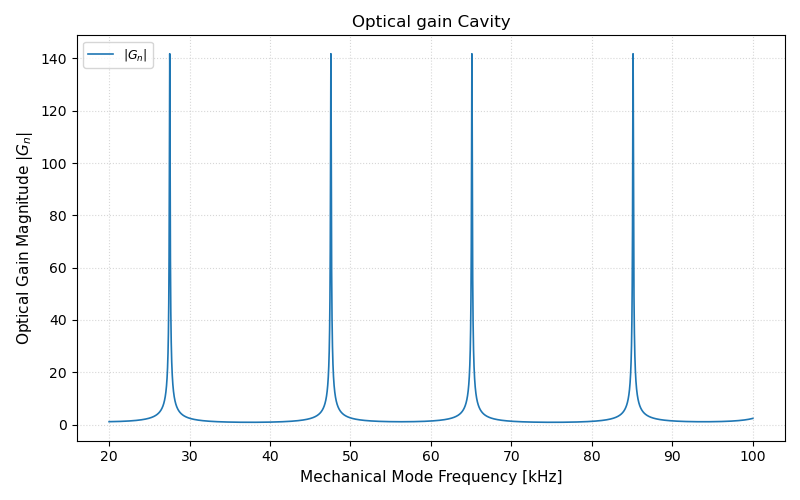

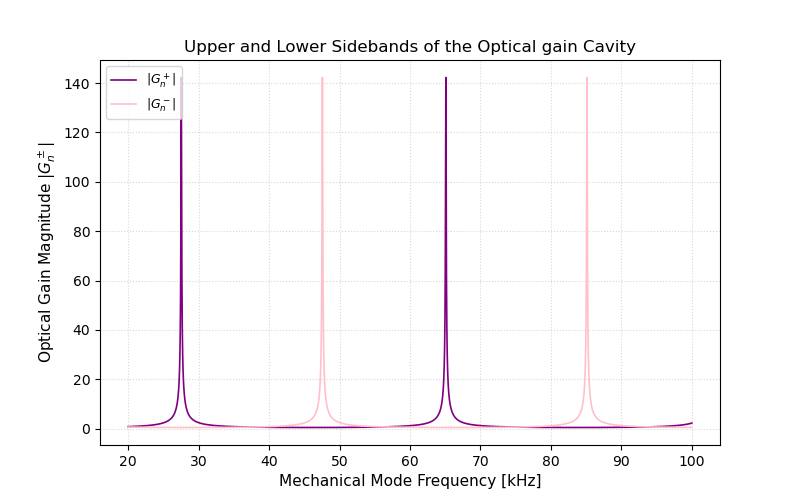

In [44]:
c = 3e8   # speed of light [m/s]
L = 3994.5  # cavity length [m]

T_I = 0.014 # input mirror power transmissivity
T_E = 1e-5   # end mirror power transmissivity
r_A = np.sqrt(1 - T_I)
r_B = np.sqrt(1 - T_E)

phi_G = np.deg2rad(156)  # round-trip Gouy phase [rad]
print(phi_G)
n = 2  # HOM order  (p + q)
phi_n = -n * phi_G   # round-trip HOM phase [rad]

f = 29950 # eigenfrequency of mode [Hz]
omega_m = 2 * np.pi * f  # mechanical mode frequency [rad/s]

G_minus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n - omega_m * L / c)))
G_plus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n + omega_m * L / c)))

Gn = G_minus - np.conj(G_plus)

print(f"G_minus = {G_minus:.4f}")
print(f"G_plus = {G_plus:.4f}")
print(f"Gn = {Gn:.4f}")
print(f"Re[Gn] = {Gn.real:.4f}")



f = np.linspace(20e3, 100e3, 50000)        # frequency array [Hz]
omega_m = 2 * np.pi * f                   # array [rad/s]

G_minus = 1 / (1 - r_A * r_B * np.exp(2j * (phi_n - omega_m * L / c)))
G_plus = 1 / (1 - r_A * r_B * np.exp(2j * (phi_n + omega_m * L / c)))
Gn = G_minus - np.conj(G_plus)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(f / 1e3, np.abs(G_plus),  lw=1.2, label=rf'$|G^+_n|$', color='purple')
ax1.plot(f / 1e3, np.abs(G_minus), lw=1.2, label=rf'$|G^-_n|$', color = 'pink')
ax1.set_title('Upper and Lower Sidebands of the Optical gain Cavity', fontsize=12)
ax1.set_xlabel('Mechanical Mode Frequency [kHz]', fontsize=11)
ax1.set_ylabel(rf'Optical Gain Magnitude $|G^\pm_n|$', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.5)

fig, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(f / 1e3, np.abs(Gn),      lw=1.2, label=rf'$|G_n|$')
ax2.set_xlabel('Mechanical Mode Frequency [kHz]', fontsize=11)
ax2.set_title('Optical gain Cavity', fontsize=12)

ax2.set_ylabel(rf'Optical Gain Magnitude $|G_n|$', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()



### <span style="color:#CD5C5C"> Step 3: Radiation Pressure: Three-Mode Interaction
This is where the magic happens. After the scattered HOM has circulated through the cavity, it returns to the same mirror surface and beats with the strong pump field and the mechanical mode. This 3 mode interaction produces a radiation-pressure force on the optic at the mechanical-mode frequency.

But, instead of scattering, this interaction will cause a radiation pressure force on the mirror. Just as in the scattering step, the spatial overlap matters. The returned optical field creates a pressure distribution across the mirror surface, but only the component of that force with the correct overlap with the mechanical mode can efficiently drive that mode again. According to Evans, this force is

$$F_{\text{rad}} = \dfrac{2}{c} E_{\text{pump}}^* \sum_{n=0}^\infty B_{m,n} E_{\text{return, n}}$$

where the factor of $(2/c)$ comes from reflection at the mirror surface. This expression is the complex radiation-pressure force amplitude at the mechanical frequency.

If the phase of the returned field is such that the radiation-pressure force adds energy to the motion, the mechanical mode is driven and its amplitude grows. If the phase is opposite, the force damps the motion instead. This is the crucial feedback step: the mirror motion first scatters light into a HOM, the cavity returns that field with a complex gain, and the returned field then produces a radiation-pressure force back on the same mechanical mode.


Output()

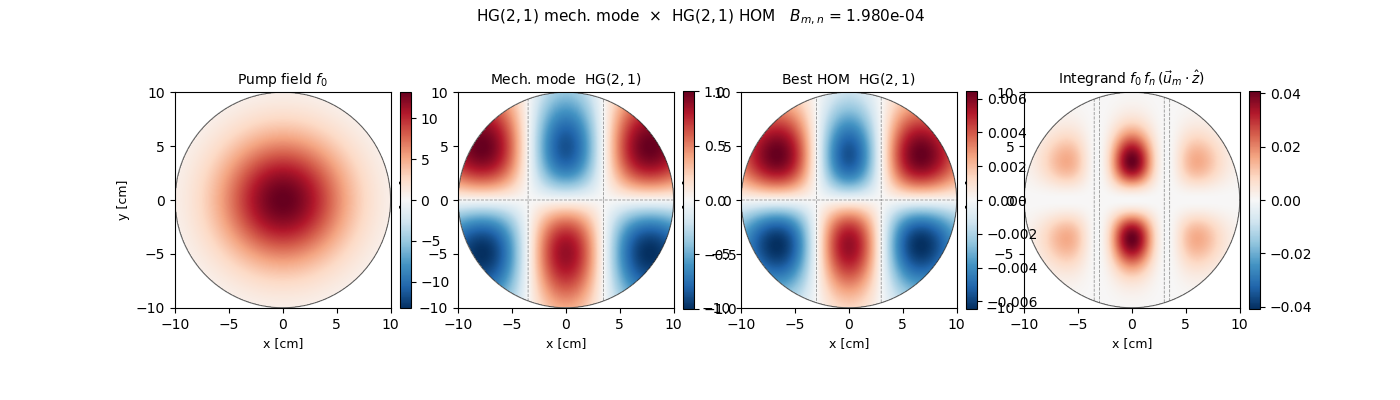

In [46]:
%matplotlib widget
"""
sliders for p_mech and q_mech update the mechanical mode,
best-overlap HOM, and integrand panels

Reference: Evans, Barsotti, Fritschel (2009), arXiv:0910.2716
           Blair PhD thesis, UWA (2017)
"""

N = 300  
mirror_r = 0.10  # mirror radius [m]
beam_waist = 0.06  # 1/e^2 beam radius [m]

x = np.linspace(-mirror_r, mirror_r, N)
X, Y = np.meshgrid(x, x)
R = np.sqrt(X**2 + Y**2)
mask = R <= mirror_r
dA = (x[1] - x[0])**2
axis_lim = [-mirror_r*100, mirror_r*100, -mirror_r*100, mirror_r*100]
theta = np.linspace(0, 2*np.pi, 300)

# functions from previous cell
def gaussian_beam(X, Y, beam_waist, mask=None):
    """
    amplitude of the pump field (TEM00 Gaussian beam).
    """
    f = np.exp(-(X**2 + Y**2) / beam_waist**2)

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA)
    f /= norm
    return f




def hermite_gauss(p, q, X, Y, w0):
    """HG_{pq} field amplitude"""
 
    Hp = hermite(p)(np.sqrt(2) * X / w0)
    Hq = hermite(q)(np.sqrt(2) * Y / w0)
    env = np.exp(-(X**2 + Y**2) / w0**2)
    f = Hp * Hq * env
    return f / (np.sqrt(np.sum(f**2)) + 1e-30)


def mechanical_mode(X, Y, p_mech, q_mech):
    """
    mech mode
    """
    scale = mirror_r * 0.7

    Hp = hermite(p_mech)(np.sqrt(2) * X / scale)
    Hq = hermite(q_mech)(np.sqrt(2) * Y / scale)
    env = np.exp(-(X**2 + Y**2) / scale**2)
    u = Hp * Hq * env
    return u / (np.max(np.abs(u)) + 1e-30)


def signed_norm(arr):
    """TwoSlopeNorm centred on 0 for signed arrays."""
    valid = arr[~np.isnan(arr)]
    vmax = np.max(np.abs(valid)) + 1e-30 if len(valid) > 0 else 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)


def compute_best_hom(u_m, f0):
    """Find HOM with largest |B_{m,n}| given mechanical mode u_m."""
    hom_pairs = [(p, q) for n in range(6)
                         for p in range(n + 1)
                         for q in [n - p]]
    B = {}
    for (p, q) in hom_pairs:
        fn = hermite_gauss(p, q, X, Y, beam_waist)
        integrand = f0 * fn * u_m
        integrand[~mask] = 0.0
        B[(p, q)] = np.sum(integrand) * dA
    best = max(B, key=lambda k: abs(B[k]))
    return best, B[best]

f0 = gaussian_beam(X, Y, beam_waist)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
plt.subplots_adjust(top=0.88, bottom=0.12)

titles_fixed = [r'Pump field $f_0$', r'Mechanical mode $\vec{u}_m \cdot \hat{z}$', r'Best-overlap HOM $f_n$', r'Integrand $f_0\,f_n\,(\vec{u}_m \cdot \hat{z})$']

# initial settings
p0, q0 = 2, 1
u_m_init = mechanical_mode(X, Y, p0, q0)
(pb, qb), B_val = compute_best_hom(u_m_init, f0)
fn_init = hermite_gauss(pb, qb, X, Y, beam_waist)
intg_init = f0 * fn_init * u_m_init
intg_init[~mask] = 0.0

init_arrays = [f0, u_m_init, fn_init, intg_init]
ims, cbs = [], []

for ax, arr, title in zip(axes, init_arrays, titles_fixed):
    disp = arr.copy()
    disp[~mask] = np.nan
    im = ax.imshow(disp, extent=axis_lim, origin='lower', cmap='RdBu_r', norm=signed_norm(disp))
    ax.plot(mirror_r*100*np.cos(theta),
            mirror_r*100*np.sin(theta),
            'k-', lw=0.8, alpha=0.5)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x [cm]', fontsize=9)
    ax.set_ylabel('y [cm]', fontsize=9)
    ax.set_aspect('equal')
    ims.append(im)
    cbs.append(cb)

fig.suptitle(
    rf'Stage 1 — overlap integrand   '
    rf'HG$({p0},{q0})$ mech. mode  ×  HG$({pb},{qb})$ HOM   '
    rf'$B_{{m,n}}$ = {B_val:.3e} m²',
    fontsize=11)


def update(p_mech, q_mech):
    u_m = mechanical_mode(X, Y, p_mech, q_mech)
    (pb, qb), B_val = compute_best_hom(u_m, f0)
    fn_best = hermite_gauss(pb, qb, X, Y, beam_waist)
    integrand_best = f0 * fn_best * u_m
    integrand_best[~mask] = 0.0

    new_arrays = [f0, u_m, fn_best, integrand_best]
    new_titles = [r'Pump field $f_0$', rf'Mech. mode  HG$({p_mech},{q_mech})$', rf'Best HOM  HG$({pb},{qb})$', r'Integrand $f_0\,f_n\,(\vec{u}_m \cdot \hat{z})$']

    for ax, im, arr, title in zip(axes, ims, new_arrays, new_titles):
        disp = arr.copy()
        disp[~mask] = np.nan
        norm = signed_norm(disp)
        im.set_data(disp)
        im.set_norm(norm)
        ax.set_title(title, fontsize=10)
        # redraw nodal contours
        for coll in ax.collections:
            coll.remove()
        ax.contour(x*100, x*100, disp, levels=[0],
                   colors='k', linewidths=0.6, linestyles='--', alpha=0.4)

    fig.suptitle(
        rf'HG$({p_mech},{q_mech})$ mech. mode  ×  HG$({pb},{qb})$ HOM   '
        rf'$B_{{m,n}}$ = {B_val:.3e}',
        fontsize=11)
    fig.canvas.draw_idle()

slider_p = widgets.IntSlider( value=2, min=0, max=5, step=1, description=r'p (mech)',style={'description_width': '80px'}, layout=widgets.Layout(width='400px'))

slider_q = widgets.IntSlider(value=1, min=0, max=5, step=1, description=r'q (mech)', style={'description_width': '80px'}, layout=widgets.Layout(width='400px'))

label = widgets.HTML(
    value='<b>Mechanical mode order:</b>')

ui = widgets.VBox([
    label,
    widgets.HBox([slider_p, slider_q])
])

out = widgets.interactive_output(update, {'p_mech': slider_p,
                                          'q_mech': slider_q})
display(ui, out)

### <span style="color:#FF474C"> Step 4: Parametric Gain and Instability

The final question is whether the radiation-pressure feedback strengthens or suppresses the mechanical motion. This is quantified by the **parametric gain** \(R_m\), which measures the strength of the optomechanical feedback relative to the intrinsic damping of mechanical mode.

The parametric gain impacts mechanical-mode buildup time according to Blair. The parametric gain equation is:

$$R_m = \frac{4\pi Q_m P_{\mathrm{circ}}}{M \omega_m^2 c \lambda_0}
\sum_{n=0}^{\infty} \operatorname{Re}(G_n)\, B_{m,n}^2.$$

This expression shows that the instability is stronger when the circulating power $(P_{\mathrm{circ}})$, the mechanical quality factor $(Q_m)$, and the spatial overlap $(B_{m,n})$ are larger.

The parametric gain is how we understand how strongly the mode interaction drives the acoustic mode. Think of it like a threshold: consider the ratio of the radiation-pressure energy fed into the mode to the mechanical energy the mode loses by damping. If the parametric gain is less than one, the the mode damping is dominating; if the parametric gain is equal to one, it is at the instability threshold; if the gain is greater than one, then the mode rings up and becomes unstable:


- $R_m < 1$: the mode is optically damped 
- $R_m = 1$: instability threshold
- $R_m > 1$: the mode rings up and becomes unstable


Let's build off of the previous parameters so that we can calculate the parametric gain caused by this 3 mode interaction. Parameters were taken from Evans et al paper, same as earlier.


Output()

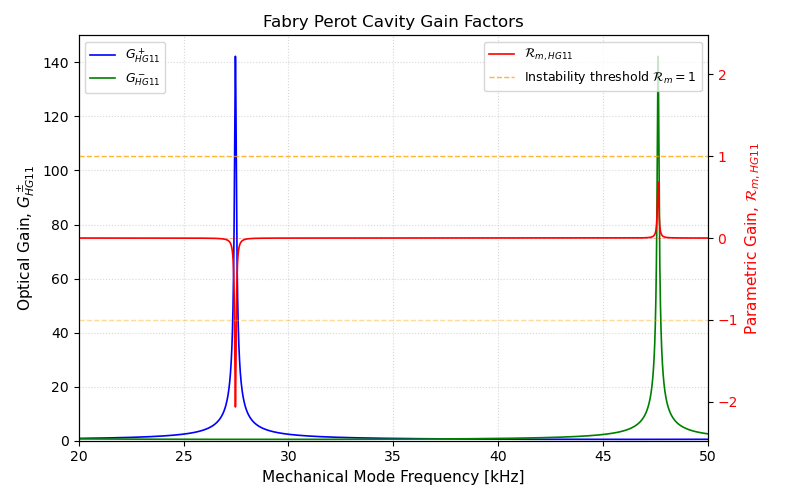

In [41]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


c = 3e8
L = 3994.5
T_I = 0.014
T_E = 1e-5
r_A = np.sqrt(1 - T_I)
r_B = np.sqrt(1 - T_E)
M = 40
lam = 1064e-9
phi_G = 2.72
n = 2
phi_n = -n * phi_G

f_m = np.linspace(20e3, 50e3, 50000)
omega_m = 2 * np.pi * f_m

fig, ax1 = plt.subplots(figsize=(8, 5))

line_Gplus, = ax1.plot([], [], color='blue',  lw=1.2, label=r'$G^+_{HG11}$')
line_Gminus, = ax1.plot([], [], color='green', lw=1.2, label=r'$G^-_{HG11}$')
ax1.set_xlabel('Mechanical Mode Frequency [kHz]', fontsize=11)
ax1.set_ylabel(r'Optical Gain, $G^\pm_{HG11}$', fontsize=11)
ax1.set_xlim(20, 50)
ax1.set_ylim(0, 150)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()
line_Rm, = ax2.plot([], [], color='red', lw=1.2, label=r'$\mathcal{R}_{m,HG11}$')
ax2.set_ylabel(r'Parametric Gain, $\mathcal{R}_{m,HG11}$', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(0,  color='red',    lw=0.6, linestyle='--', alpha=0.4)
ax2.axhline(1,  color='orange', lw=1.0, linestyle='--', alpha=0.8,
            label=r'Instability threshold $\mathcal{R}_m = 1$')
ax2.axhline(-1, color='orange', lw=1.0, linestyle='--', alpha=0.4)
ax2.legend(loc='upper right', fontsize=9)
ax1.set_title('Fabry Perot Cavity Gain Factors', fontsize=12)

plt.tight_layout()


def update(P_MW, Q_m_log, B_m_n):
    P = P_MW * 1e6
    Q_m = 10**Q_m_log

    G_plus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n + omega_m * L / c)))
    G_minus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n - omega_m * L / c)))
    Gn = G_minus - np.conj(G_plus)

    prefactor = (4 * np.pi * Q_m * P) / (M * omega_m**2 * c * lam)
    R_m = prefactor * Gn.real * B_m_n**2

    line_Gplus.set_data(f_m / 1e3,  np.abs(G_plus))
    line_Gminus.set_data(f_m / 1e3, np.abs(G_minus))
    line_Rm.set_data(f_m / 1e3, R_m)

    R_max = max(np.max(np.abs(R_m)) * 1.2, 1.5)
    ax2.set_ylim(-R_max, R_max)

    fig.canvas.draw_idle()

# sliders

style = {'description_width': '180px'}
layout = widgets.Layout(width='500px')

slider_P = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1,
    description='Power P [MW]',
    style=style, layout=layout)

slider_Q = widgets.FloatSlider(
    value=7.0, min=5.0, max=9.0, step=0.1,
    description='log₁₀(Q_m)',
    style=style, layout=layout)

slider_B = widgets.FloatSlider(
    value=0.21, min=0.0, max=1.0, step=0.01,
    description='Overlap $B_{m,n}$',
    style=style, layout=layout)

label = widgets.HTML(
    value='<b>Tune parameters — $\\mathcal{R}_m > 1$ means unstable</b>')

ui = widgets.VBox([
    label,
    slider_P,
    slider_Q,
    slider_B
])

out = widgets.interactive_output(update, {
    'P_MW':    slider_P,
    'Q_m_log': slider_Q,
    'B_m_n':   slider_B
})

display(ui, out)

### How are PIs detuned or damped in LIGO?

To avoid lock loss, parametric instabilities must either be **detuned** or **damped**. There are a couple of different techniques that can be utilized to help mitigate these excited modes: either by changing the spatial overlap by shifting the frequencies of the problematic modes, or to reduce overall the mechanical mode Q factor of the optic (reducing either the mechanical contribution $(Q_m)$ or the optical feedback term $(\operatorname{Re}(G_n))$).

<div style="text-align: center;" width="400">

![Damping PIs in LIGO](damping_pi_ligo.png)

<p style="font-size: 12px;">Figure 1: Damping PIs in LIGO. From Blair et al. (2017)<sup>[3]</sup></p>

</div>


#### 1. Thermal Detuning using Ring Heaters
Ring heaters attack the optical side of the feedback loop by shifting the HOM resonance frequencies away from mechanical mode frequencies. They change the test-mass radius of curvature (RoC), which changes the cavity Gouy phase and therefore the frequency spacing of the higher-order optical modes. By shifting the transverse optical mode resonances away from the mechanical-mode frequencies, the optical feedback is reduced and the unstable interaction can be detuned. $^{[5]}$. 




#### 2. Passive Damping using Acoustic Mode Dampers (AMDs)

Another approach is to reduce the mechanical quality factor of the unstable acoustic modes directly. Each test mass is equipped with four different AMDs distributed on the optic's flats. Each AMD consists of a base, a reaction mass, and a shunted piezoelectric shear plate that acts like a lossy tunable spring. When a problematic acoustic mode is excited, the AMD absorbs part of its vibrational energy and increases the mode’s effective damping, thereby lowering its effective $(Q_m)$.


<div style="display: flex; justify-content: center; gap: 40px; align-items: flex-start;">

  <div style="text-align: center;">
    <img src="amd.png" width="500">
    <p><b>LIGO Test Mass with AMDs</b><sup>[7]</sup></p>
  </div>

  <div style="text-align: center;">
    <img src="amd_damping.png" width="400">
    <p><b>Damping parametric instabilities with AMDs</b><sup>[7]</sup></p>
  </div>

</div>

#### 3. Active Damping using Electrostatic Drive (ESD)

The electrostatic drive (ESD) damps parametric instabilities by applying a feedback force directly to the test mass surface at the same frequency but with opposite phase. This actively damps the mechanical modes of the test mass $^{[4]}$. The ESD also provides longitudinal actuation to hold the arm cavities on resonance.


<div style="display: flex; justify-content: center; gap: 40px; align-items: flex-start;">

  <div style="text-align: center;">
    <img src="esd.png" width="400">
    <p><b>LIGO Reaction Test Mass with ESD</b><sup>[7]</sup></p>
  </div>

  <div style="text-align: center;">
    <img src="esd_damping.png" width="700">
    <p><b>Damping parametric instabilities with ESD</b><sup>[7]</sup></p>
  </div>

</div>

## <span style="color:lightblue"> Resources

[1] Blair, Carl. *Parametric Instability in Gravitational Wave Detectors.* Diss. University of Western Australia, 2017.

[2] Evans, M., L. Barsotti, and P. Fritschel. "A General Approach to Optomechanical Parametric Instabilities." *arXiv,* 14 Oct. 2009, arXiv:0910.2716v1

[3] Blair, Carl, et al. "First Demonstration of Electrostatic Damping of Parametric Instability at Advanced LIGO." *Physical Review Letters*, vol. 118, no. 15, Apr. 2017, doi:10.1103/PhysRevLett.118.151102.

[4] Miller, John, et al. "Damping Parametric Instabilities in Future Gravitational Wave Detectors by Means of Electrostatic Actuators." *arXiv*, 12 Apr. 2017, arXiv:1704.03587.

[5] Bin Wu et al 2020, "Contoured Thermal Deformation of Mirror Surface for Detuning Parametric Instability in an Optical Cavity" Class. Quantum Grav. 37 125003

[6] V. B. Braginsky, S. E. Strigin, and S. P. Vyatchanin, “Parametric Oscillatory Instability in Fabry-Perot (FP) Interferometer,” arXiv:gr-qc/0107079v2, 2001.

[7] S. Biscans, S. Gras, C. D. Blair, J. Driggers, M. Evans, P. Fritschel, T. Hardwick, and G. Mansell,
“Suppressing parametric instabilities in LIGO using low-noise acoustic mode dampers,”
arXiv:1909.07805, 2019.

[8] Schiworski, M. G. (2024). Development and application of phase cameras for advanced gravitational wave detectors (PhD thesis, The University of Adelaide). LIGO-P2500114-v1.

[9] H. P. Daveloza *et al*., “Controlling calibration errors in gravitational-wave detectors by precise location of calibration forces,” *J. Phys.: Conf. Ser.* **363**, 012007 (2012).

[10] COMSOL image of Mechanical Modes made Caroline Capuano (me) and Steven Penn